<a href="https://colab.research.google.com/github/KhenCahyo13/MyCampus-Jobsheet/blob/smt-5/pcvk/week-5/Week5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Import Libraries

In [2]:
import cv2 as cv
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import math
import glob
from google.colab.patches import cv2_imshow

# D1 Practicum - Histogram

## Practicum - Create Manual Histogram

In [ ]:
# Read image
img = cv.imread('lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Get image size
height, width, depth = np.shape(img)
names = np.arange(256)

# Histogram array initialization from each channels
red = [0] * 256
green = [0] * 256
blue = [0] * 256

# Count total occurences of each entities
for y in range(0, height):
    for x in range(0, width):
        red[img[y][x][0]] += 1
        green[img[y][x][1]] += 1
        blue[img[y][x][2]] += 1

# plotting
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle("Histogram RGB Plot")

fig.text(0.09, 0.5, 'Total of Occurences', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Colors Intensity', ha='center')

axs[0].bar(names, red, color='red')
axs[1].bar(names, green, color='green')
axs[2].bar(names, blue, color='blue')

plt.show()

## Number 1 Task - NumPy Histogram

In [ ]:
img = cv.imread('lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Separated channel colors
r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

# Count histogram using numPy
hist_r, bins_r = np.histogram(r, bins=256, range=(0, 256))
hist_g, bins_g = np.histogram(g, bins=256, range=(0, 256))
hist_b, bins_b = np.histogram(b, bins=256, range=(0, 256))

# Plotting
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle("Histogram RGB Plot (NumPy)")

fig.text(0.09, 0.5, 'Total of Occurences', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Colors Intensity', ha='center')

axs[0].bar(names, hist_r, color='red')
axs[1].bar(names, hist_g, color='green')
axs[2].bar(names, hist_b, color='blue')

plt.show()

## Number 2 Task - KTM Lama

In [ ]:
# Read image
img = cv.imread('KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Separated channel colors
r, g, b = img[:,:,0], img[:,:,1], img[:,:,2]

# Count histogram results using numPy
hist_r, bins_r = np.histogram(r, bins=256, range=(0, 256))
hist_g, bins_g = np.histogram(g, bins=256, range=(0, 256))
hist_b, bins_b = np.histogram(b, bins=256, range=(0, 256))

# plotting
names = np.arange(256)
fig, axs = plt.subplots(1, 3, figsize=(20, 5), sharex=True, sharey=True)
fig.suptitle("Histogram RGB Plot - KTM lama.jpg")

fig.text(0.09, 0.5, 'Total of Occurences', va='center', rotation='vertical')
fig.text(0.5, 0.04, 'Colors Intensity', ha='center')

axs[0].bar(names, hist_r, color='red')
axs[1].bar(names, hist_g, color='green')
axs[2].bar(names, hist_b, color='blue')

plt.show()

# D2 Practicum - Equalization Histogram

## Number 1 Task - Compare Histogram Equalization Results

In [ ]:
# Read image
img = cv.imread('lena_lc.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Separated channel colors
r, g, b = cv.split(img)

# Equalization Histogram for each channels
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Merge back equalization channel results
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Histogram plotting function
def plot_hist(channel, color):
    hist, bins = np.histogram(channel, bins=256, range=(0,256))
    plt.bar(np.arange(256), hist, color=color, alpha=0.7)

# Plot results before and after
fig, axs = plt.subplots(2, 4, figsize=(20, 8))

# Real citra
axs[0,0].imshow(img)
axs[0,0].set_title("Citra Asli")
axs[0,0].axis("off")

# Real citra histogram
plt.sca(axs[0,1]); plot_hist(r, 'red'); axs[0,1].set_title("Hist Red (Asli)")
plt.sca(axs[0,2]); plot_hist(g, 'green'); axs[0,2].set_title("Hist Green (Asli)")
plt.sca(axs[0,3]); plot_hist(b, 'blue'); axs[0,3].set_title("Hist Blue (Asli)")

# Equalization citra results
axs[1,0].imshow(img_eq)
axs[1,0].set_title("Equalization Citra Results Histogram")
axs[1,0].axis("off")

# Equalization citra results histogram
plt.sca(axs[1,1]); plot_hist(r_eq, 'red'); axs[1,1].set_title("Hist Red (Equalized)")
plt.sca(axs[1,2]); plot_hist(g_eq, 'green'); axs[1,2].set_title("Hist Green (Equalized)")
plt.sca(axs[1,3]); plot_hist(b_eq, 'blue'); axs[1,3].set_title("Hist Blue (Equalized)")

plt.tight_layout()
plt.show()

## Number 2 Task - Equalization Histogram CV2

In [ ]:
# Read image
image = cv.imread("lena_lc.jpg")
image = cv.cvtColor(image, cv.COLOR_BGR2RGB)

# RGB channel split
b, g, r = cv.split(image)

# Equalization Histogram for each channel using cv2.equalizeHist
b_equalized = cv.equalizeHist(b)
g_equalized = cv.equalizeHist(g)
r_equalized = cv.equalizeHist(r)

# Merge back channels after equalization
image_equalized = cv.merge((b_equalized, g_equalized, r_equalized))

# Histogram plotting function
def plot_hist(channel, color):
    hist = cv.calcHist([channel], [0], None, [256], [0,256])
    plt.bar(np.arange(256), hist.ravel(), color=color, alpha=0.7)

# Comparation plot
fig, axs = plt.subplots(2, 4, figsize=(20, 8))

# Real citra
axs[0,0].imshow(image)
axs[0,0].set_title("Citra Asli")
axs[0,0].axis("off")

# Real citra histogram
plt.sca(axs[0,1]); plot_hist(r, 'red'); axs[0,1].set_title("Hist Red (Asli)")
plt.sca(axs[0,2]); plot_hist(g, 'green'); axs[0,2].set_title("Hist Green (Asli)")
plt.sca(axs[0,3]); plot_hist(b, 'blue'); axs[0,3].set_title("Hist Blue (Asli)")

# Equalized citra
axs[1,0].imshow(image_equalized)
axs[1,0].set_title("Citra Equalized (cv2.equalizeHist)")
axs[1,0].axis("off")

# Equalized citra histogram
plt.sca(axs[1,1]); plot_hist(r_equalized, 'red'); axs[1,1].set_title("Hist Red (Equalized)")
plt.sca(axs[1,2]); plot_hist(g_equalized, 'green'); axs[1,2].set_title("Hist Green (Equalized)")
plt.sca(axs[1,3]); plot_hist(b_equalized, 'blue'); axs[1,3].set_title("Hist Blue (Equalized)")

plt.tight_layout()
plt.show()

# D2 Practicum Questions

## Answer Number 1

In [ ]:
# Read image
img = cv.imread('lena.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channel colors
r, g, b = cv.split(img)

# Equalization on each channels
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Merge back equalization results
img_eq = cv.merge((r_eq, g_eq, b_eq))

# PSNR function
def psnr(img1, img2):
    mse = np.mean((img1 - img2) ** 2)
    if mse == 0:
        return float('inf')
    PIXEL_MAX = 255.0
    return 20 * np.log10(PIXEL_MAX / np.sqrt(mse))

# Count PSNR between real citra dan equalization results
psnr_value = psnr(img, img_eq)
print("PSNR between real citra and equalizd:", psnr_value)

# Plot hasil citra
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(img)
axs[0].set_title("Real Citra")
axs[0].axis("off")

axs[1].imshow(img_eq)
axs[1].set_title("Equalized Citra")
axs[1].axis("off")
plt.show()

## Answer Number 2

In [ ]:
# Read image
img = cv.imread('KTM lama.jpg')
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Split channels
r, g, b = cv.split(img)

# Histogram equalization per channel
r_eq = cv.equalizeHist(r)
g_eq = cv.equalizeHist(g)
b_eq = cv.equalizeHist(b)

# Merge equalized channels
img_eq = cv.merge((r_eq, g_eq, b_eq))

# Fungsi plotting histogram
def plot_hist(channel, color):
    hist, bins = np.histogram(channel, bins=256, range=(0, 256))
    plt.bar(np.arange(256), hist, color=color, alpha=0.7)

# Plot results
fig, axs = plt.subplots(2, 4, figsize=(20, 10))

# --- Row 1: Real Citra & histogram ---
axs[0,0].imshow(img)
axs[0,0].set_title("Citra Asli")
axs[0,0].axis("off")

plt.sca(axs[0,1]); plot_hist(r, 'red'); axs[0,1].set_title("Hist Red (Asli)")
plt.sca(axs[0,2]); plot_hist(g, 'green'); axs[0,2].set_title("Hist Green (Asli)")
plt.sca(axs[0,3]); plot_hist(b, 'blue'); axs[0,3].set_title("Hist Blue (Asli)")

# --- Row 2: Citra equalized & histogram ---
axs[1,0].imshow(img_eq)
axs[1,0].set_title("Citra Equalized")
axs[1,0].axis("off")

plt.sca(axs[1,1]); plot_hist(r_eq, 'red'); axs[1,1].set_title("Hist Red (Equalized)")
plt.sca(axs[1,2]); plot_hist(g_eq, 'green'); axs[1,2].set_title("Hist Green (Equalized)")
plt.sca(axs[1,3]); plot_hist(b_eq, 'blue'); axs[1,3].set_title("Hist Blue (Equalized)")

plt.tight_layout()
plt.show()

# D3 Practicum Task - Dethering

## Answer Number 1

In [ ]:
# Read image as RGB
img = cv.imread("lena.jpg")
img = cv.cvtColor(img, cv.COLOR_BGR2RGB)

# Convert to float for calculation
img = img.astype(float)

# Citra size
height, width, channels = img.shape

# Floyd-Steinberg dithering for each channels
for y in range(height - 1):
    for x in range(1, width - 1):
        for c in range(channels):
            old_pixel = img[y, x, c]
            new_pixel = 255 if old_pixel >= 128 else 0
            img[y, x, c] = new_pixel
            error = old_pixel - new_pixel

            # Spread the errors to neighbors
            img[y, x+1, c]   += error * 7/16
            img[y+1, x-1, c] += error * 3/16
            img[y+1, x, c]   += error * 5/16
            img[y+1, x+1, c] += error * 1/16

# Convert back to uint8
img_dithered = np.clip(img, 0, 255).astype(np.uint8)

# Results plot
fig, axs = plt.subplots(1, 2, figsize=(12, 6))
axs[0].imshow(cv.cvtColor(cv.imread("lena.jpg"), cv.COLOR_BGR2RGB))
axs[0].set_title("Real Citra (RGB)")
axs[0].axis("off")

axs[1].imshow(img_dithered)
axs[1].set_title("Citra after Floyd-Steinberg Dithering (RGB)")
axs[1].axis("off")

plt.show()

## Answer Number 2

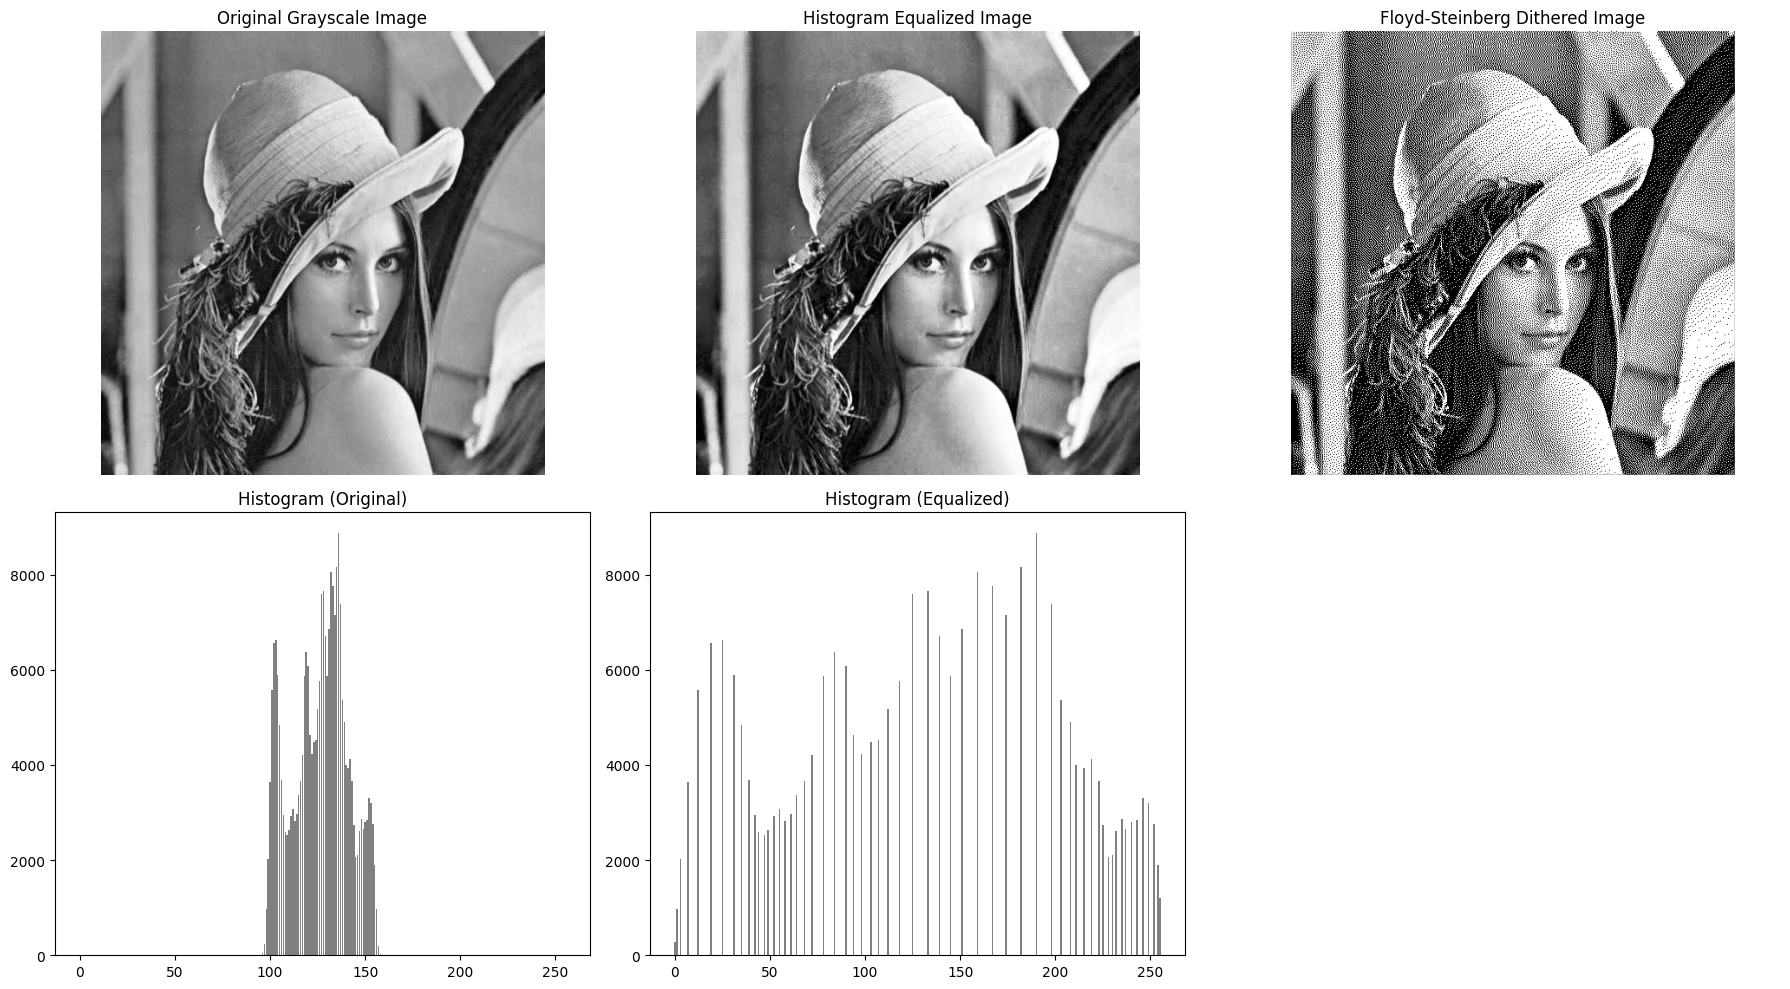

In [21]:
# 1. Read the image and convert to grayscale
img = cv.imread("lena_lc.jpg", cv.IMREAD_GRAYSCALE)

# 2. Apply Histogram Equalization
img_eq = cv.equalizeHist(img)

# 3. Apply Floyd-Steinberg dithering on the equalized image
img_fs = img_eq.astype(float)
height, width = img_fs.shape

for y in range(height - 1):
    for x in range(1, width - 1):
        old_pixel = img_fs[y, x]
        new_pixel = 255 if old_pixel >= 128 else 0
        img_fs[y, x] = new_pixel
        error = old_pixel - new_pixel

        # Spread the error to the neighboring pixels
        img_fs[y, x+1]   += error * 7/16
        img_fs[y+1, x-1] += error * 3/16
        img_fs[y+1, x]   += error * 5/16
        img_fs[y+1, x+1] += error * 1/16

# Convert back to uint8
img_dithered = np.clip(img_fs, 0, 255).astype(np.uint8)

# 4. Plot the results
fig, axs = plt.subplots(2, 3, figsize=(18, 10))

# Original grayscale image
axs[0,0].imshow(img, cmap="gray")
axs[0,0].set_title("Original Grayscale Image")
axs[0,0].axis("off")

# Equalized image
axs[0,1].imshow(img_eq, cmap="gray")
axs[0,1].set_title("Histogram Equalized Image")
axs[0,1].axis("off")

# Dithered image
axs[0,2].imshow(img_dithered, cmap="gray")
axs[0,2].set_title("Floyd-Steinberg Dithered Image")
axs[0,2].axis("off")

# Histogram of original image
hist_orig, _ = np.histogram(img.ravel(), bins=256, range=(0,256))
axs[1,0].bar(np.arange(256), hist_orig, color="gray")
axs[1,0].set_title("Histogram (Original)")

# Histogram of equalized image
hist_eq, _ = np.histogram(img_eq.ravel(), bins=256, range=(0,256))
axs[1,1].bar(np.arange(256), hist_eq, color="gray")
axs[1,1].set_title("Histogram (Equalized)")

# Empty subplot for alignment
axs[1,2].axis("off")

plt.tight_layout()
plt.show()